# Analysis of the AGP in different cases with 1st order phase transition

#### Imports

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from src.annealing_utils import (
    get_driver_hamiltonian,
    get_longitudinal_hamiltonian,
    computational_basis,
)
from src.schedule_utils import SchedulerModel, Schedule
from ManyBodyQutip.qutip_class import SpinOperator
from src.utils import Sector
from src.optimalcontrol_magic_constrain_utils import (
    JaxSchedulerModelMagic,
    JaxTrainerMagic,
)
import pickle
from src.annealing_utils import compute_exact_AGP
from src.annealing_utils import agp_osd

### Maximum weighted independent set

#### Problem Hamiltonian parameters

In [2]:
import numpy as np
from src.annealing_utils import get_longitudinal_hamiltonian, get_driver_hamiltonian


def mwis_jij_hz(n0, n1, dW, Jzz):
    n = n0 + n1
    G0 = list(range(n0))
    G1 = list(range(n0, n0 + n1))

    jij = np.zeros((n, n))
    for i in G0:
        for j in G1:
            jij[i, j] = Jzz
            jij[j, i] = Jzz

    h0 = n1 * Jzz - 2 * (1 + dW) / n0
    h1 = n0 * Jzz - 2 / n1

    hz = np.zeros(n)
    for i in G0:
        hz[i] = +h0
    for j in G1:
        hz[j] = +h1

    return jij, hz

Hyperparameters

In [3]:
# ── Example: n0=2, n1=3, matching the paper's 5-qubit instance ───────────────
n0, n1 = 2, 3
n_qubits = n0 + n1
dW = 0.01  # small weight imbalance → perturbative crossing
Jzz = 5.33  # edge penalty (closed-system example in paper)

jij, hz = mwis_jij_hz(n0, n1, dW, Jzz)

print("Jij matrix:")
print(np.round(jij, 3))
print("\nhz vector:")
print(np.round(hz, 3))

Jij matrix:
[[0.   0.   5.33 5.33 5.33]
 [0.   0.   5.33 5.33 5.33]
 [5.33 5.33 0.   0.   0.  ]
 [5.33 5.33 0.   0.   0.  ]
 [5.33 5.33 0.   0.   0.  ]]

hz vector:
[14.98  14.98   9.993  9.993  9.993]


Hamiltonians

In [4]:
# ── Feed into your src functions ─────────────────────────────────────────────
nqubits = n0 + n1
target_hamiltonian = get_longitudinal_hamiltonian(jij, hz)  # sparse scipy matrix
driver_hamiltonian = get_driver_hamiltonian(nqubits=nqubits)  # sparse scipy matrix

Energy Levels of Annealing Evolution

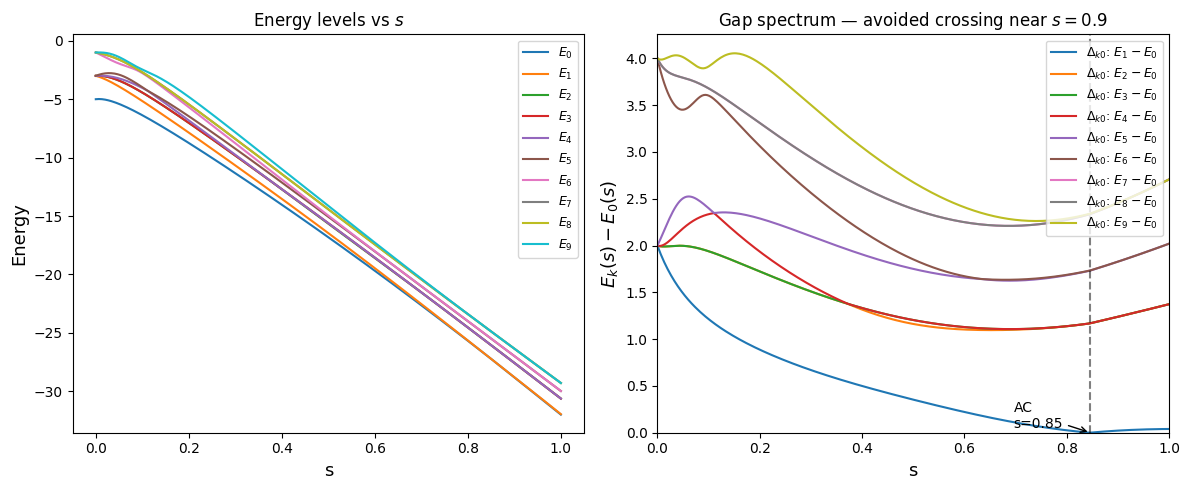

Minimum gap Δ₁₀ = 0.000668 at s = 0.846


In [5]:
from scipy.sparse.linalg import eigsh

# --- Sweep s ---
grid_size = 300
n_levels = 10
s_vals = np.linspace(0, 1, grid_size)
spectra = np.zeros((len(s_vals), n_levels))
psi_history = []

for idx, s in enumerate(s_vals):
    total_hamiltonian = (1 - s) * driver_hamiltonian + s * target_hamiltonian
    vals, psis = eigsh(total_hamiltonian, k=n_levels, which="SA")
    order = np.argsort(vals)
    # (dim, n_eigs), sorted by energy
    spectra[idx] = np.sort(vals.real)

    psi_history.append(psis[:, order[0]])

E0 = spectra[:, 0]  # ground state energy at each s

# --- Plot 1: Raw energy levels ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
for k in range(n_levels):
    ax.plot(s_vals, spectra[:, k], label=f"$E_{k}$")
ax.set_xlabel("s", fontsize=13)
ax.set_ylabel("Energy", fontsize=13)
ax.set_title("Energy levels vs $s$")
ax.legend(fontsize=9)

# --- Plot 2: Gaps Δ_k0 = E_k - E_0  (what the paper plots) ---
ax = axes[1]
colors = ["C1", "C2", "C3", "C4", "C5"]
for k in range(1, n_levels):
    gap = spectra[:, k] - E0
    ax.plot(s_vals, gap, label=f"$\\Delta_{{k0}}$: $E_{k}-E_0$")

ax.set_xlabel("s", fontsize=13)
ax.set_ylabel("$E_k(s) - E_0(s)$", fontsize=13)
ax.set_title("Gap spectrum — avoided crossing near $s=0.9$")
ax.legend(fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, None)

# Mark the minimum gap
min_gap = spectra[:, 1] - E0
s_mingap = s_vals[np.argmin(min_gap)]
ax.axvline(
    s_mingap, color="k", linestyle="--", alpha=0.5, label=f"min gap @ s={s_mingap:.2f}"
)
ax.annotate(
    f"AC\ns={s_mingap:.2f}",
    xy=(s_mingap, min_gap.min()),
    xytext=(s_mingap - 0.15, min_gap.min() + 0.05),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=10,
)

plt.tight_layout()
plt.savefig("avoided_crossing.png", dpi=150)
plt.show()

print(f"Minimum gap Δ₁₀ = {min_gap.min():.6f} at s = {s_mingap:.3f}")

#### Compute the AGP for this case

Pointwise values of the AGP

[3.25695597e-19 3.36798670e-03 1.27606569e-02 3.38362723e-02
 2.11913793e-01 7.38121291e-01]
4.668659745116274
XYXXX  q=0.0352  c=-6.8919+0.0000j
YXXXX  q=0.0352  c=-6.8919+0.0000j
XXXYX  q=0.0352  c=6.8874+0.0000j
XXXXY  q=0.0352  c=6.8874+0.0000j
XXYXX  q=0.0352  c=6.8874+0.0000j
YYYXX  q=0.0351  c=-6.8801+0.0000j
YYXXY  q=0.0351  c=-6.8801+0.0000j
YYXYX  q=0.0351  c=-6.8801+0.0000j
YXYXY  q=0.0351  c=6.8756+0.0000j
YXXYY  q=0.0351  c=6.8756+0.0000j
YXYYX  q=0.0351  c=6.8756+0.0000j
XYYYX  q=0.0351  c=6.8756+0.0000j
XYXYY  q=0.0351  c=6.8756+0.0000j
XYYXY  q=0.0351  c=6.8756+0.0000j
XXYYY  q=0.0351  c=-6.8711+0.0000j
YYYYY  q=0.0350  c=6.8638+0.0000j
XYIXX  q=0.0049  c=-0.9571+0.0000j
XYXIX  q=0.0049  c=-0.9571+0.0000j
XYXXI  q=0.0049  c=-0.9571+0.0000j
YXXXI  q=0.0049  c=-0.9571+0.0000j
YXXIX  q=0.0049  c=-0.9571+0.0000j
YXIXX  q=0.0049  c=-0.9571+0.0000j
XXXYI  q=0.0049  c=0.9567+0.0000j
XXXIY  q=0.0049  c=0.9567+0.0000j
XXIYX  q=0.0049  c=0.9567+0.0000j
XXIXY  q=0.0049  c=0.9567+0

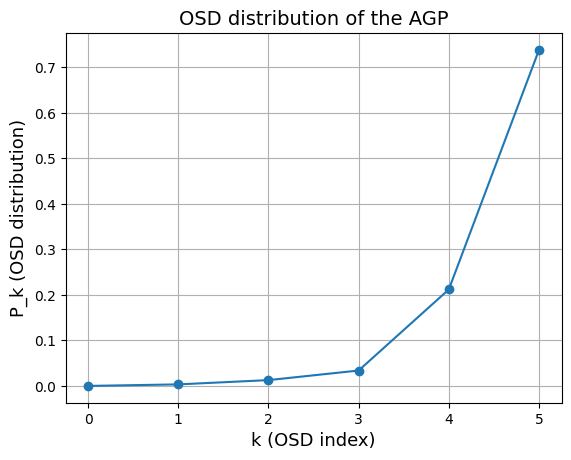

[3.25695597e-19 2.03101231e-14 9.60017418e-04 ... 9.02820358e-15
 4.62869562e-05 1.18427164e-18]


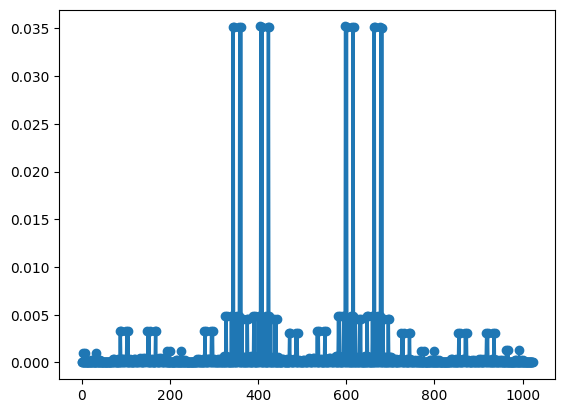

In [6]:
A = compute_exact_AGP(
    driver_hamiltonian, target_hamiltonian, lam=0.846
)  # your existing function
result = agp_osd(A, n=n_qubits, top_k=100)


print(result["P_k"])  # (n+1,) OSD
print(result["mean_size"])  # mu
for label, q, c in result["top_strings"]:
    print(f"{label}  q={q:.4f}  c={c:.4f}")

plt.plot(result["P_k"], marker="o")
plt.xlabel("k (OSD index)", fontsize=13)
plt.ylabel("P_k (OSD distribution)", fontsize=13)
plt.title("OSD distribution of the AGP", fontsize=14)
plt.grid()
plt.show()

print(result["probs"])
plt.plot(result["probs"], marker="o")
plt.show()

Analysis over s

Computing AGP OSD for each s:   0%|          | 0/300 [00:00<?, ?it/s]

Computing AGP OSD for each s: 100%|██████████| 300/300 [00:13<00:00, 22.20it/s]


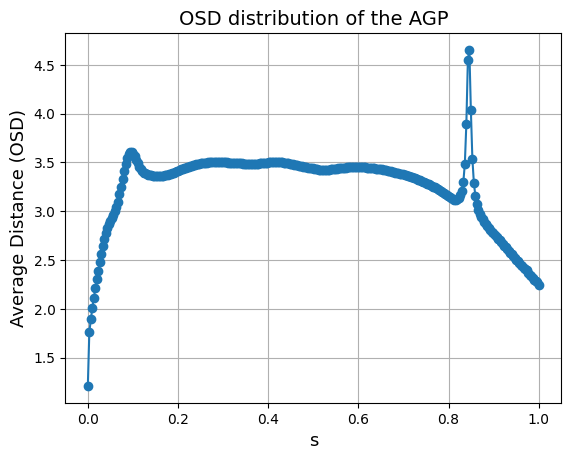

In [7]:
from tqdm.asyncio import tqdm

avg_distance = []
agp_entropy = []
tbar = tqdm(s_vals, desc="Computing AGP OSD for each s")
for s in tbar:
    a_s = compute_exact_AGP(driver_hamiltonian, target_hamiltonian, lam=s)
    result = agp_osd(a_s, n=n_qubits)
    probs = result["probs"]
    avg_distance.append(result["mean_size"])
    agp_entropy.append(
        -np.sum(probs[probs > 0] * np.log(probs[probs > 0]) / np.log(4**n_qubits - 1))
    )  # normalize by max entropy

plt.plot(s_vals, avg_distance, marker="o")
plt.xlabel("s", fontsize=13)
plt.ylabel("Average Distance (OSD)", fontsize=13)
plt.title("OSD distribution of the AGP", fontsize=14)
plt.grid()
plt.show()

Concentration of the AGP

Computing AGP OSD: 100%|██████████| 300/300 [00:13<00:00, 22.17it/s]


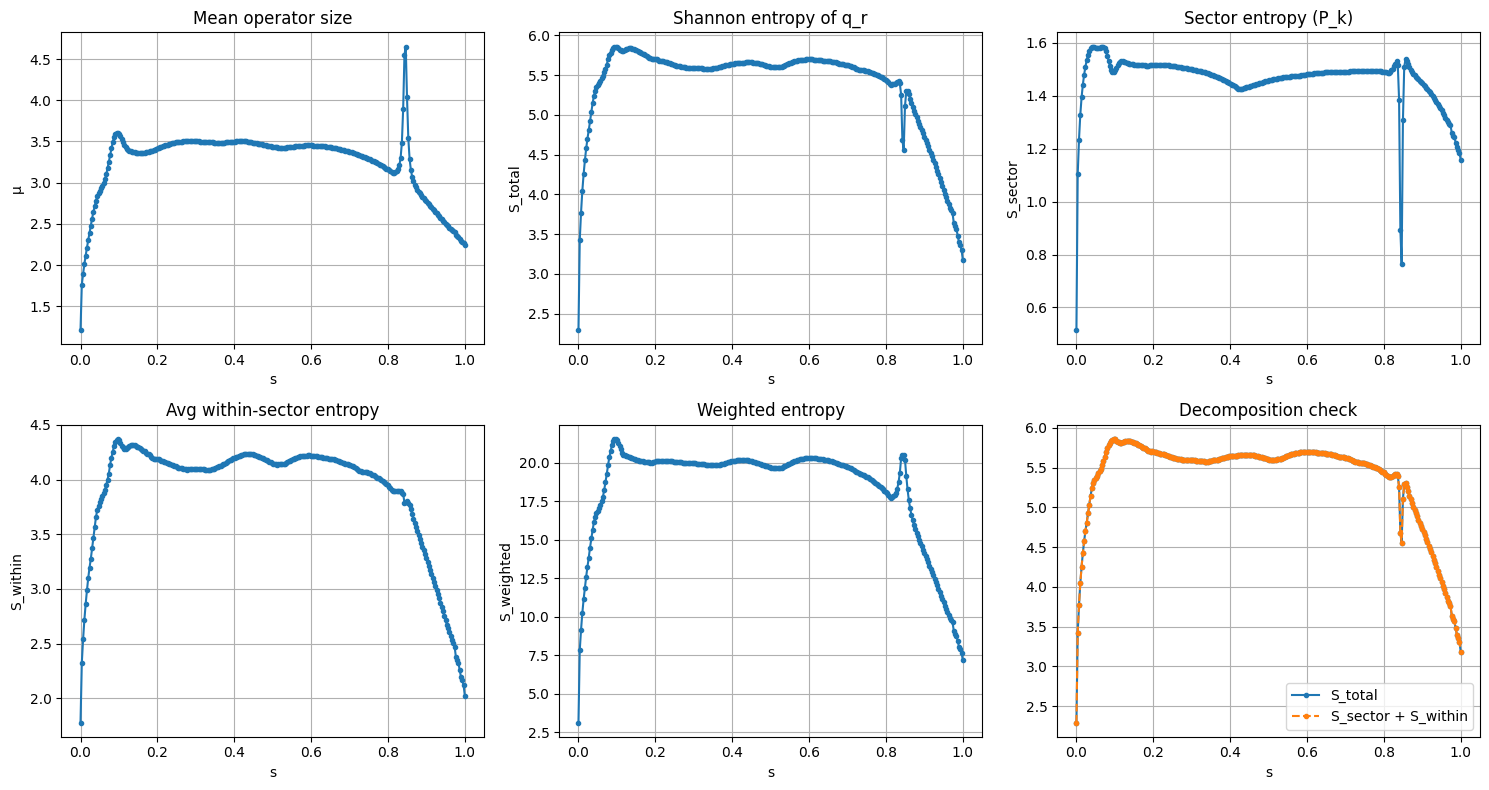

In [8]:
from tqdm import tqdm
import numpy as np
from scipy.special import comb

avg_distance = []
agp_entropy = []
S_sector_list = []
S_within_avg_list = []
S_weighted_list = []
mu_list = []

tbar = tqdm(s_vals, desc="Computing AGP OSD")
for s in tbar:
    a_s = compute_exact_AGP(driver_hamiltonian, target_hamiltonian, lam=s)
    result = agp_osd(a_s, n=n_qubits)

    probs = result["probs"]  # (4^n,)
    P_k = result["P_k"]  # (n+1,)
    mu = result["mean_size"]

    # weights for each Pauli string
    weights = np.array(
        [sum(1 for c in label if c != "I") for label in result["labels"]]
    )

    # ── Shannon entropy of q_r ────────────────────────────────────────────
    mask = probs > 0
    S_total = -np.sum(probs[mask] * np.log(probs[mask]))

    # ── sector entropy  S = -sum_k P_k log P_k ───────────────────────────
    pk = P_k[P_k > 0]
    S_sector = -np.sum(pk * np.log(pk))

    # ── within-sector entropy at each k ──────────────────────────────────
    S_within = np.zeros(n_qubits + 1)
    for k in range(n_qubits + 1):
        mask_k = (weights == k) & (probs > 0)
        if P_k[k] < 1e-14:
            continue
        q_k = probs[mask_k] / P_k[k]
        S_within[k] = -np.sum(q_k * np.log(q_k))

    S_within_avg = np.sum(P_k * S_within)  # = S_total - S_sector (exact)

    # ── weighted entropy: weight(r) * (-log q_r) ─────────────────────────
    S_weighted = -np.sum(probs[mask] * weights[mask] * np.log(probs[mask]))

    # ── store ─────────────────────────────────────────────────────────────
    avg_distance.append(mu)
    agp_entropy.append(S_total)
    S_sector_list.append(S_sector)
    S_within_avg_list.append(S_within_avg)
    S_weighted_list.append(S_weighted)
    mu_list.append(mu)

# convert
avg_distance = np.array(avg_distance)
agp_entropy = np.array(agp_entropy)
S_sector_arr = np.array(S_sector_list)
S_within_avg_arr = np.array(S_within_avg_list)
S_weighted_arr = np.array(S_weighted_list)
mu_arr = np.array(mu_list)

# ── plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0, 0].plot(s_vals, mu_arr, marker="o", ms=3)
axes[0, 0].set(xlabel="s", ylabel="μ", title="Mean operator size")
axes[0, 0].grid()

axes[0, 1].plot(s_vals, agp_entropy, marker="o", ms=3)
axes[0, 1].set(xlabel="s", ylabel="S_total", title="Shannon entropy of q_r")
axes[0, 1].grid()

axes[0, 2].plot(s_vals, S_sector_arr, marker="o", ms=3)
axes[0, 2].set(xlabel="s", ylabel="S_sector", title="Sector entropy (P_k)")
axes[0, 2].grid()

axes[1, 0].plot(s_vals, S_within_avg_arr, marker="o", ms=3)
axes[1, 0].set(xlabel="s", ylabel="S_within", title="Avg within-sector entropy")
axes[1, 0].grid()

axes[1, 1].plot(s_vals, S_weighted_arr, marker="o", ms=3)
axes[1, 1].set(xlabel="s", ylabel="S_weighted", title="Weighted entropy")
axes[1, 1].grid()

# decomposition check: S_total = S_sector + S_within_avg
axes[1, 2].plot(s_vals, agp_entropy, label="S_total", ms=3, marker="o")
axes[1, 2].plot(
    s_vals,
    S_sector_arr + S_within_avg_arr,
    label="S_sector + S_within",
    ms=3,
    marker="o",
    linestyle="--",
)
axes[1, 2].set(xlabel="s", title="Decomposition check")
axes[1, 2].legend()
axes[1, 2].grid()

plt.tight_layout()
plt.show()

#### Stabilizer Renyi Entropy

In [9]:
from src.jax_utils import SREJax
from src.utils import EntanglementEntropy
from tqdm import trange

# build once — reuse for all states
sre = SREJax(n_qubits=nqubits)
entanglement_entropy = EntanglementEntropy(nqubits=nqubits, n_A=nqubits // 2)

# single state
magic = []
magic_gs_level = []
entanglement_entropy_gs_level_history = []
for i in trange(s_vals.shape[0]):
    state = psi_history[i]
    magic_gs_level.append(sre((state)))
    entanglement_entropy_gs_level_history.append(
        entanglement_entropy.von_neumann((state))
    )

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


Building Pauli index tables for n=5 (1,024 Paulis)...
Done.
Bipartition: A=2 qubits (4d), B=3 qubits (8d)


100%|██████████| 300/300 [00:00<00:00, 793.00it/s]


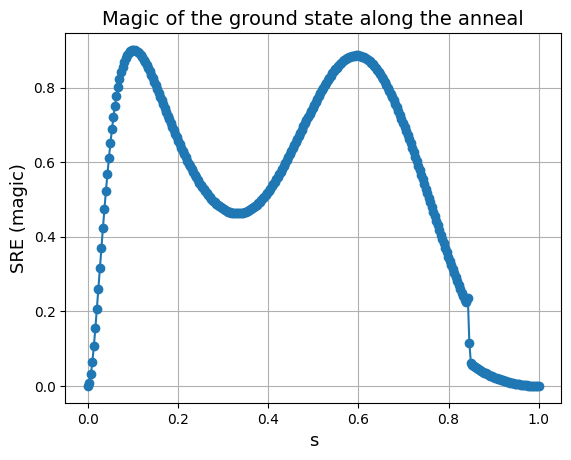

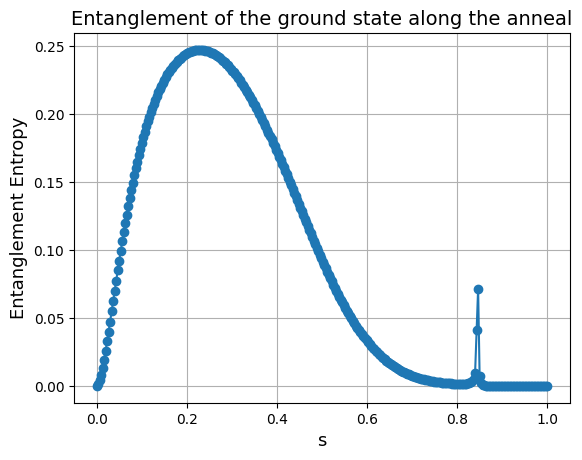

In [10]:
plt.plot(s_vals, magic_gs_level, marker="o")
plt.xlabel("s", fontsize=13)
plt.ylabel("SRE (magic)", fontsize=13)
plt.title("Magic of the ground state along the anneal", fontsize=14)
plt.grid()
plt.show()

plt.plot(s_vals, entanglement_entropy_gs_level_history, marker="o")
plt.xlabel("s", fontsize=13)
plt.ylabel("Entanglement Entropy", fontsize=13)
plt.title("Entanglement of the ground state along the anneal", fontsize=14)
plt.grid()
plt.show()

#### Operator delocalization of the Unitary transformation

In [11]:
from src.annealing_utils import operator_spreading_agp
import matplotlib.pyplot as plt

results = operator_spreading_agp(
    driver_hamiltonian,
    target_hamiltonian,
    lam_values=s_vals,
    n_eigs=None,
)

# plot mean operator size for each initial local operator
fig, ax = plt.subplots(figsize=(8, 4))
for name in [f"X_{i}" for i in range(n_qubits)]:
    ax.plot(s_vals, results[name]["mu"], label=name)
ax.axhline(3 * n_qubits / 4, ls="--", color="gray", label="Haar")
ax.set(xlabel="λ", ylabel="μ(λ)", title="Operator spreading under AGP unitary")
ax.legend()
plt.show()

Computing OSD:   0%|          | 0/300 [00:00<?, ?it/s]


NameError: name 'pauli_decompose_operator' is not defined